In [1]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================
!pip install kagglehub -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import time
import json
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print("All libraries loaded successfully!")


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries loaded successfully!


In [2]:
# ============================================================
# CELL 2: Load Preprocessed Data from Feature Engineering Notebook
# Mount Google Drive and set paths
from google.colab import drive
drive.mount('/content/drive')
output_dir = '/content/drive/MyDrive/DeepSentinel/DeepSentinel_Output_v2'

# If files not found, remind user to run Feature Engineering first
if not os.path.exists(output_dir):
    print("Preprocessed files not found in Google Drive!")
    print("Please run the Feature Engineering notebook first.")
    print(f"Expected path: {output_dir}")

    # Auto-download and process
    import kagglehub
    path = kagglehub.dataset_download("ealaxi/paysim1")
    csv_files = list(Path(path).glob("*.csv"))
    CSV_PATH = csv_files[0]

    print(f"Loading raw PaySim from: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH)

    # Quick feature engineering
    df['F1_log_amount'] = np.log1p(df['amount'])
    df['F2_amount_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)
    df['F3_balance_consistency'] = (
        np.abs(df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']) < 0.01
    ).astype(int)
    df['F4_balance_change_ratio'] = (df['newbalanceOrig'] - df['oldbalanceOrg']) / (df['oldbalanceOrg'] + 1)
    df['F5_dest_balance_ratio'] = df['newbalanceDest'] / (df['oldbalanceDest'] + 1)
    df['F6_hour'] = (df['step'] % 24) / 24
    df['F7_day'] = (df['step'] / 24) / 30
    # FIX: Compute P95 on normal-only (avoid fraud leakage) + vectorize
    p95_by_type = df[df['isFraud'] == 0].groupby('type')['amount'].quantile(0.95)
    df['F8_is_large'] = (df['amount'] > df['type'].map(p95_by_type)).astype(int)
    # F9-F13: mule-network and destination-side features
    df['F9_dest_starts_empty']   = (df['oldbalanceDest'] == 0).astype(int)
    df['F10_recipient_emptied']  = ((df['newbalanceDest'] == 0) & (df['amount'] > 0)).astype(int)
    velocity = df.groupby('nameOrig').size()
    df['F11_account_velocity']   = np.log1p(df['nameOrig'].map(velocity))
    df['F12_round_amount']       = ((df['amount'] % 1000 == 0) & (df['amount'] >= 10000)).astype(int)
    df['F13_zero_dest_history']  = ((df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == df['amount'])).astype(int)

    feature_cols = ['F1_log_amount', 'F2_amount_balance_ratio', 'F3_balance_consistency',
                    'F4_balance_change_ratio', 'F5_dest_balance_ratio', 'F6_hour',
                    'F7_day', 'F8_is_large',
                    'F9_dest_starts_empty', 'F10_recipient_emptied',
                    'F11_account_velocity', 'F12_round_amount', 'F13_zero_dest_history']

    types_to_keep = ['TRANSFER', 'CASH_OUT', 'PAYMENT']
    df_stratified = df[df['type'].isin(types_to_keep)].copy()

    os.makedirs(output_dir, exist_ok=True)
    for txn_type in types_to_keep:
        subset = df_stratified[df_stratified['type'] == txn_type]
        subset[subset['isFraud'] == 0][feature_cols].to_csv(f'{output_dir}/{txn_type}_normal_features.csv', index=False)
        subset[feature_cols + ['isFraud']].to_csv(f'{output_dir}/{txn_type}_all_features.csv', index=False)

    print("Feature engineering complete!")

feature_cols = ['F1_log_amount', 'F2_amount_balance_ratio', 'F3_balance_consistency',
                'F4_balance_change_ratio', 'F5_dest_balance_ratio', 'F6_hour',
                'F7_day', 'F8_is_large',
                'F9_dest_starts_empty', 'F10_recipient_emptied',
                'F11_account_velocity', 'F12_round_amount', 'F13_zero_dest_history']

# Load all normal data (for training)
print("Loading preprocessed data...")
transfer_normal = pd.read_csv(f'{output_dir}/TRANSFER_normal_features.csv')
cashout_normal = pd.read_csv(f'{output_dir}/CASH_OUT_normal_features.csv')
payment_normal = pd.read_csv(f'{output_dir}/PAYMENT_normal_features.csv')

# Load all data with labels (for evaluation)
transfer_all = pd.read_csv(f'{output_dir}/TRANSFER_all_features.csv')
cashout_all = pd.read_csv(f'{output_dir}/CASH_OUT_all_features.csv')
payment_all = pd.read_csv(f'{output_dir}/PAYMENT_all_features.csv')

# Combine ALL normal data for global VAE training
global_normal = pd.concat([transfer_normal, cashout_normal, payment_normal], ignore_index=True)

# Combine ALL data for evaluation
global_all = pd.concat([transfer_all, cashout_all, payment_all], ignore_index=True)

print(f"\nData loaded:")
print(f"  Global normal (for training): {len(global_normal):,} rows")
print(f"  Global all (for evaluation):  {len(global_all):,} rows")
print(f"  Fraud transactions:           {global_all['isFraud'].sum():,}")
print(f"  Features:                     {len(feature_cols)}")


Mounted at /content/drive
Loading preprocessed data...

Data loaded:
  Global normal (for training): 4,913,691 rows
  Global all (for evaluation):  4,921,904 rows
  Fraud transactions:           8,213
  Features:                     13


In [3]:
# ============================================================
# CELL 3: Data Preprocessing - Normalize Features
# ============================================================
print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# Fit scaler on normal data only (no data leakage)
scaler = MinMaxScaler()
X_train_raw = global_normal[feature_cols].values
X_train = scaler.fit_transform(X_train_raw)

# Transform all data for evaluation
X_all = scaler.transform(global_all[feature_cols].values)
y_all = global_all['isFraud'].values

# Train/test split (80/20 on normal data)
split_idx = int(len(X_train) * 0.8)
X_train_vae = X_train[:split_idx]
X_val_vae = X_train[split_idx:]

print(f"  Training set:    {X_train_vae.shape[0]:,} normal transactions")
print(f"  Validation set:  {X_val_vae.shape[0]:,} normal transactions")
print(f"  Evaluation set:  {len(X_all):,} transactions ({y_all.sum():,} fraud)")
print(f"  Feature range:   [0, 1] after MinMax scaling")


DATA PREPROCESSING
  Training set:    3,930,952 normal transactions
  Validation set:  982,739 normal transactions
  Evaluation set:  4,921,904 transactions (8,213 fraud)
  Feature range:   [0, 1] after MinMax scaling


In [4]:
# ============================================================
# CELL 4: Build Global VAE Model (Configuration A Baseline)
# ============================================================
print("=" * 60)
print("BUILDING GLOBAL VAE MODEL (Config A - Baseline)")
print("=" * 60)

# VAE Architecture Parameters
INPUT_DIM = 13      # 13 features (F1-F13)
HIDDEN_1 = 32       # First hidden layer
HIDDEN_2 = 16       # Second hidden layer
LATENT_DIM = 8      # Latent space dimension
INITIAL_LR = 0.001  # Learning rate

# Encoder
encoder_inputs = keras.Input(shape=(INPUT_DIM,), name='encoder_input')
x = layers.Dense(HIDDEN_1, activation='relu', name='enc_hidden1')(encoder_inputs)
x = layers.Dense(HIDDEN_2, activation='relu', name='enc_hidden2')(x)
z_mean = layers.Dense(LATENT_DIM, name='z_mean')(x)
z_log_var = layers.Dense(LATENT_DIM, name='z_log_var')(x)

# Reparameterization trick
def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, name='z')([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
decoder_inputs = keras.Input(shape=(LATENT_DIM,), name='decoder_input')
x = layers.Dense(HIDDEN_2, activation='relu', name='dec_hidden1')(decoder_inputs)
x = layers.Dense(HIDDEN_1, activation='relu', name='dec_hidden2')(x)
decoder_outputs = layers.Dense(INPUT_DIM, activation='sigmoid', name='dec_output')(x)

decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

# Full VAE
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        self.beta = tf.Variable(0.0, trainable=False, name='beta')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss (per feature)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )

            # KL divergence loss (per latent dimension)
            # Free Bits: enforce minimum 0.01 KL per dimension (lowered from 0.1 to prevent KL collapse)
            kl_per_dim = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            free_bits_lambda = 0.01
            kl_per_dim_clamped = tf.maximum(kl_per_dim, free_bits_lambda)
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_per_dim_clamped, axis=1))

            # Total loss with beta-annealing
            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=1))
        kl_per_dim = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_per_dim_clamped = tf.maximum(kl_per_dim, 0.01)
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_per_dim_clamped, axis=1))
        total_loss = recon_loss + self.beta * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Build and compile
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR))

print(f"\nVAE Architecture:")
print(f"  Input:       {INPUT_DIM} features")
print(f"  Encoder:     {INPUT_DIM} -> {HIDDEN_1} -> {HIDDEN_2} -> {LATENT_DIM} (mean + logvar)")
print(f"  Latent:      {LATENT_DIM} dimensions")
print(f"  Decoder:     {LATENT_DIM} -> {HIDDEN_2} -> {HIDDEN_1} -> {INPUT_DIM}")
print(f"  Free Bits:   0.1 per dimension")
print(f"  Beta:        Annealed from 0 to 1 over 10 epochs")

encoder.summary()
decoder.summary()


BUILDING GLOBAL VAE MODEL (Config A - Baseline)

VAE Architecture:
  Input:       13 features
  Encoder:     13 -> 32 -> 16 -> 8 (mean + logvar)
  Latent:      8 dimensions
  Decoder:     8 -> 16 -> 32 -> 13
  Free Bits:   0.1 per dimension
  Beta:        Annealed from 0 to 1 over 10 epochs


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_hidden1 (Dense) │ (None, 32)        │        448 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_hidden2 (Dense) │ (None, 16)        │        528 │ enc_hidden1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 8)         │        136 │ enc_hidden2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 8)         │        136 │ enc_hidden2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 8)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,248 (4.88 KB)

 Trainable params: 1,248 (4.88 KB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_hidden1 (Dense)             │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_hidden2 (Dense)             │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_output (Dense)              │ (None, 13)             │           429 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,117 (4.36 KB)

 Trainable params: 1,117 (4.36 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ============================================================
# CELL 5: Train Global VAE with Beta-Annealing
# ============================================================
print("=" * 60)
print("TRAINING GLOBAL VAE (Config A)")
print("=" * 60)

EPOCHS = 50
BATCH_SIZE = 256
ANNEAL_EPOCHS = 10  # Beta goes from 0 to 1 over first 10 epochs

# Beta-annealing callback
class BetaAnnealing(keras.callbacks.Callback):
    def __init__(self, vae_model, anneal_epochs):
        super().__init__()
        self.vae_model = vae_model
        self.anneal_epochs = anneal_epochs

    def on_epoch_begin(self, epoch, logs=None):
        new_beta = min(1.0, epoch / self.anneal_epochs)
        self.vae_model.beta.assign(new_beta)
        if epoch < self.anneal_epochs or epoch % 10 == 0:
            print(f"  Beta = {new_beta:.2f}")

beta_callback = BetaAnnealing(vae, ANNEAL_EPOCHS)

# Train
print(f"\nTraining for {EPOCHS} epochs...")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training samples: {X_train_vae.shape[0]:,}")
print(f"  Validation samples: {X_val_vae.shape[0]:,}")
print()

t0 = time.time()
history = vae.fit(
    X_train_vae,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=X_val_vae,   # FIX: pass array directly (not single-element tuple)
    callbacks=[beta_callback],
    verbose=1
)
train_time = time.time() - t0

print(f"\nTraining complete in {train_time:.1f}s ({train_time/60:.1f} min)")


TRAINING GLOBAL VAE (Config A)

Training for 50 epochs...
  Batch size: 256
  Training samples: 3,930,952
  Validation samples: 982,739

  Beta = 0.00
Epoch 1/50
15356/15356 ━━━━━━━━━━━━━━━━━━━━ 68s 4ms/step - kl_loss: 283.0243 - recon_loss: 0.0410 - total_loss: 0.0410 - val_kl_loss: 438.3403 - val_recon_loss: 0.0725 - val_total_loss: 0.0725
  Beta = 0.10
Epoch 2/50
15356/15356 ━━━━━━━━━━━━━━━━━━━━ 56s 4ms/step - kl_loss: 2.3151 - recon_loss: 0.1725 - total_loss: 0.4040 - val_kl_loss: 2.6060 - val_recon_loss: 0.2832 - val_total_loss: 0.5438
  Beta = 0.20
Epoch 3/50
15356/15356 ━━━━━━━━━━━━━━━━━━━━ 55s 4ms/step - kl_loss: 1.6670 - recon_loss: 0.2136 - total_loss: 0.5470 - val_kl_loss: 2.1081 - val_recon_loss: 0.3313 - val_total_loss: 0.7529
  Beta = 0.30
Epoch 4/50
15356/15356 ━━━━━━━━━━━━━━━━━━━━ 57s 4ms/step - kl_loss: 1.3057 - recon_loss: 0.2922 - total_loss: 0.6839 - val_kl_loss: 1.7202 - val_recon_loss: 0.4233 - val_total_loss: 0.9394
  Beta = 0.40
Epoch 5/50
15356/15356 ━━━━━━━━━━

TRAINING HISTORY


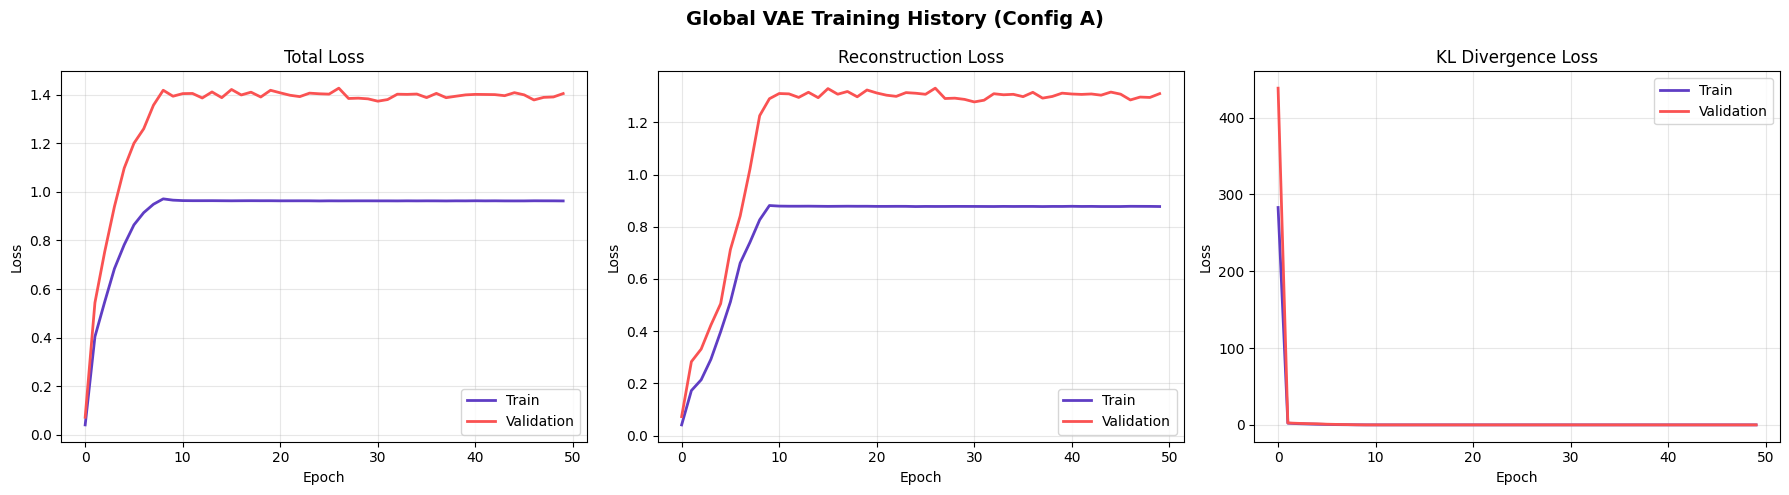

Saved: training_history.png


In [6]:
# ============================================================
# CELL 6: Training History Visualization
# ============================================================
print("=" * 60)
print("TRAINING HISTORY")
print("=" * 60)

results_dir = '/content/drive/MyDrive/DeepSentinel/DeepSentinel_Results_v2'
os.makedirs(results_dir, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Global VAE Training History (Config A)', fontsize=14, fontweight='bold')

# Total loss
axes[0].plot(history.history['total_loss'], label='Train', color='#5f3dc4', linewidth=2)
axes[0].plot(history.history['val_total_loss'], label='Validation', color='#fa5252', linewidth=2)
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reconstruction loss
axes[1].plot(history.history['recon_loss'], label='Train', color='#5f3dc4', linewidth=2)
axes[1].plot(history.history['val_recon_loss'], label='Validation', color='#fa5252', linewidth=2)
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# KL loss
axes[2].plot(history.history['kl_loss'], label='Train', color='#5f3dc4', linewidth=2)
axes[2].plot(history.history['val_kl_loss'], label='Validation', color='#fa5252', linewidth=2)
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_dir}/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_history.png")


In [7]:
# ============================================================
# CELL 7: Compute Anomaly Scores on ALL Data
# ============================================================
print("=" * 60)
print("COMPUTING ANOMALY SCORES")
print("=" * 60)

# Get encoder outputs and reconstructions for all data
z_mean_all, z_log_var_all, z_all = vae.encoder.predict(X_all, batch_size=1024, verbose=0)
X_reconstructed = vae.decoder.predict(z_all, batch_size=1024, verbose=0)

# Signal 1: Per-feature reconstruction error
recon_error_per_feature = (X_all - X_reconstructed) ** 2
total_recon_error = np.sum(recon_error_per_feature, axis=1)

# Signal 2: Per-dimension KL divergence
kl_per_dim = -0.5 * (1 + z_log_var_all - z_mean_all**2 - np.exp(z_log_var_all))
total_kl = np.sum(kl_per_dim, axis=1)

# Combined anomaly score
# FIX: Z-score normalize each signal first so neither dominates due to scale.
# Recon error and KL divergence are on completely different scales (~0.1 vs ~3.0).
# Without normalization, alpha=0.5 effectively becomes ~alpha=0.03 for recon.
recon_mean, recon_std = total_recon_error.mean(), total_recon_error.std() + 1e-8
kl_mean, kl_std = total_kl.mean(), total_kl.std() + 1e-8
recon_norm = (total_recon_error - recon_mean) / recon_std
kl_norm = (total_kl - kl_mean) / kl_std

alpha = 0.5  # Equal weighting (now genuinely equal because both signals are z-scored)
anomaly_scores = alpha * recon_norm + (1 - alpha) * kl_norm

print(f"  Anomaly scores computed for {len(anomaly_scores):,} transactions")
print(f"  Recon error (raw) - Mean: {total_recon_error.mean():.4f}, Std: {total_recon_error.std():.4f}")
print(f"  KL divergence (raw) - Mean: {total_kl.mean():.4f}, Std: {total_kl.std():.4f}")
print(f"  Combined score (z-scored) - Mean: {anomaly_scores.mean():.4f}, Std: {anomaly_scores.std():.4f}")

print(f"\n  Fraud score stats:")
print(f"    Mean: {anomaly_scores[y_all == 1].mean():.4f}")
print(f"    Std:  {anomaly_scores[y_all == 1].std():.4f}")
print(f"  Normal score stats:")
print(f"    Mean: {anomaly_scores[y_all == 0].mean():.4f}")
print(f"    Std:  {anomaly_scores[y_all == 0].std():.4f}")


COMPUTING ANOMALY SCORES
  Anomaly scores computed for 4,921,904 transactions
  Recon error (raw) - Mean: 0.9653, Std: 0.5877
  KL divergence (raw) - Mean: 0.0870, Std: 0.0145
  Combined score (z-scored) - Mean: -0.0000, Std: 0.8423

  Fraud score stats:
    Mean: 0.8047
    Std:  0.7051
  Normal score stats:
    Mean: -0.0013
    Std:  0.8419


In [8]:
# ============================================================
# CELL 8: Threshold Optimization using Precision-Recall Curve
# ============================================================
print("=" * 60)
print("THRESHOLD OPTIMIZATION")
print("=" * 60)

# FIX: Split into tuning + test sets to avoid optimizing threshold on the same data
# we evaluate on (otherwise reported metrics are over-optimistic).
np.random.seed(42)
n_total = len(y_all)
tune_idx = np.random.choice(n_total, size=int(0.3 * n_total), replace=False)
test_idx = np.setdiff1d(np.arange(n_total), tune_idx)

# Tune threshold on the tune split
precisions_tune, recalls_tune, thresholds_tune = precision_recall_curve(
    y_all[tune_idx], anomaly_scores[tune_idx]
)
f1_tune = 2 * (precisions_tune * recalls_tune) / (precisions_tune + recalls_tune + 1e-8)
optimal_idx = np.argmax(f1_tune)
optimal_threshold = thresholds_tune[optimal_idx]

print(f"  Tuning set size: {len(tune_idx):,} | Test set size: {len(test_idx):,}")
print(f"  Optimal threshold (from tuning set): {optimal_threshold:.4f}")
print(f"  Tuning set scores at this threshold:")
print(f"    Precision: {precisions_tune[optimal_idx]:.4f}")
print(f"    Recall:    {recalls_tune[optimal_idx]:.4f}")
print(f"    F1-score:  {f1_tune[optimal_idx]:.4f}")

# Apply threshold on the held-out test set for the FINAL reported metrics
y_pred = np.zeros(n_total, dtype=int)
y_pred[test_idx] = (anomaly_scores[test_idx] >= optimal_threshold).astype(int)
# Also keep PR curve for visualization (computed on test set only)
precisions, recalls, thresholds_pr = precision_recall_curve(
    y_all[test_idx], anomaly_scores[test_idx]
)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)


THRESHOLD OPTIMIZATION
  Tuning set size: 1,476,571 | Test set size: 3,445,333
  Optimal threshold (from tuning set): 2.7035
  Tuning set scores at this threshold:
    Precision: 0.0365
    Recall:    0.0098
    F1-score:  0.0155


In [9]:
# ============================================================
# CELL 9: Full Evaluation Metrics
# ============================================================
print("=" * 60)
print("EVALUATION METRICS (Config A - Global VAE, Global Threshold)")
print("=" * 60)

# FIX: Evaluate on held-out test set only (threshold was tuned on tune_idx)
y_test = y_all[test_idx]
y_pred_test = y_pred[test_idx]
scores_test = anomaly_scores[test_idx]

precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
auc_roc = roc_auc_score(y_test, scores_test)

# False positive rate
tn = ((y_test == 0) & (y_pred_test == 0)).sum()
fp = ((y_test == 0) & (y_pred_test == 1)).sum()
fn = ((y_test == 1) & (y_pred_test == 0)).sum()
tp = ((y_test == 1) & (y_pred_test == 1)).sum()
fpr = fp / (fp + tn)

print(f"\n  Config A Results:")
print(f"  {'='*40}")
print(f"  Precision:          {precision:.4f}")
print(f"  Recall:             {recall:.4f}")
print(f"  F1-Score:           {f1:.4f}")
print(f"  AUC-ROC:            {auc_roc:.4f}")
print(f"  False Positive Rate:{fpr:.4f}")
print(f"  {'='*40}")
print(f"  True Positives:     {tp:,}")
print(f"  False Positives:    {fp:,}")
print(f"  True Negatives:     {tn:,}")
print(f"  False Negatives:    {fn:,}")

# Per-type evaluation
print(f"\n  Per-Type Breakdown:")
print(f"  {'Type':<12} {'Recall':>8} {'Precision':>10} {'F1':>8} {'AUC':>8} {'Fraud':>8} {'Detected':>10}")
print(f"  {'-'*70}")

per_type_metrics = {}

for txn_type in ['TRANSFER', 'CASH_OUT', 'PAYMENT']:
    type_data = pd.read_csv(f'{output_dir}/{txn_type}_all_features.csv')
    type_X = scaler.transform(type_data[feature_cols].values)
    type_y = type_data['isFraud'].values

    z_m, z_lv, z_s = vae.encoder.predict(type_X, batch_size=1024, verbose=0)
    type_recon = vae.decoder.predict(z_s, batch_size=1024, verbose=0)
    type_re = np.sum((type_X - type_recon)**2, axis=1)
    type_kl = np.sum(-0.5 * (1 + z_lv - z_m**2 - np.exp(z_lv)), axis=1)
    # FIX: Apply same z-score normalization used for the global anomaly score
    type_re_norm = (type_re - recon_mean) / recon_std
    type_kl_norm = (type_kl - kl_mean) / kl_std
    type_scores = alpha * type_re_norm + (1 - alpha) * type_kl_norm
    type_pred = (type_scores >= optimal_threshold).astype(int)

    if type_y.sum() > 0:
        t_recall = recall_score(type_y, type_pred)
        t_precision = precision_score(type_y, type_pred, zero_division=0)
        t_f1 = f1_score(type_y, type_pred, zero_division=0)
        t_auc = roc_auc_score(type_y, type_scores)
        detected = int(type_pred[type_y == 1].sum())
        per_type_metrics[txn_type] = {
            'recall': float(t_recall), 'precision': float(t_precision),
            'f1': float(t_f1), 'auc': float(t_auc),
            'fraud_count': int(type_y.sum()), 'detected': detected,
            'recon_mean': float(type_re.mean()),
        }
        print(f"  {txn_type:<12} {t_recall:>8.4f} {t_precision:>10.4f} {t_f1:>8.4f} {t_auc:>8.4f} {int(type_y.sum()):>8} {detected:>10}")
    else:
        type_fp = int(type_pred.sum())
        type_fpr = type_fp / len(type_y)
        per_type_metrics[txn_type] = {
            'recall': None, 'precision': None, 'f1': None, 'auc': None,
            'fraud_count': 0, 'fp_count': type_fp, 'fpr': float(type_fpr),
            'recon_mean': float(type_re.mean()),
        }
        print(f"  {txn_type:<12} {'N/A':>8} {'N/A':>10} {'N/A':>8} {'N/A':>8} {0:>8} {'FP='+str(type_fp):>10}")

# Save metrics
metrics = {
    'config': 'A - Global VAE, Global Threshold',
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'auc_roc': float(auc_roc),
    'fpr': float(fpr),
    'threshold': float(optimal_threshold),
    'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
    'train_time_seconds': float(train_time),
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
}
with open(f'{results_dir}/config_a_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"\nMetrics saved to: config_a_metrics.json")


EVALUATION METRICS (Config A - Global VAE, Global Threshold)

  Config A Results:
  Precision:          0.0395
  Recall:             0.0104
  F1-Score:           0.0165
  AUC-ROC:            0.7839
  False Positive Rate:0.0004
  True Positives:     60
  False Positives:    1,459
  True Negatives:     3,438,107
  False Negatives:    5,707

  Per-Type Breakdown:
  Type           Recall  Precision       F1      AUC    Fraud   Detected
  ----------------------------------------------------------------------
  TRANSFER       0.0176     0.9863   0.0345   0.9432     4097         72
  CASH_OUT       0.0005     0.6667   0.0010   0.9369     4116          2
  PAYMENT           N/A        N/A      N/A      N/A        0    FP=1985

Metrics saved to: config_a_metrics.json


EVALUATION VISUALIZATIONS


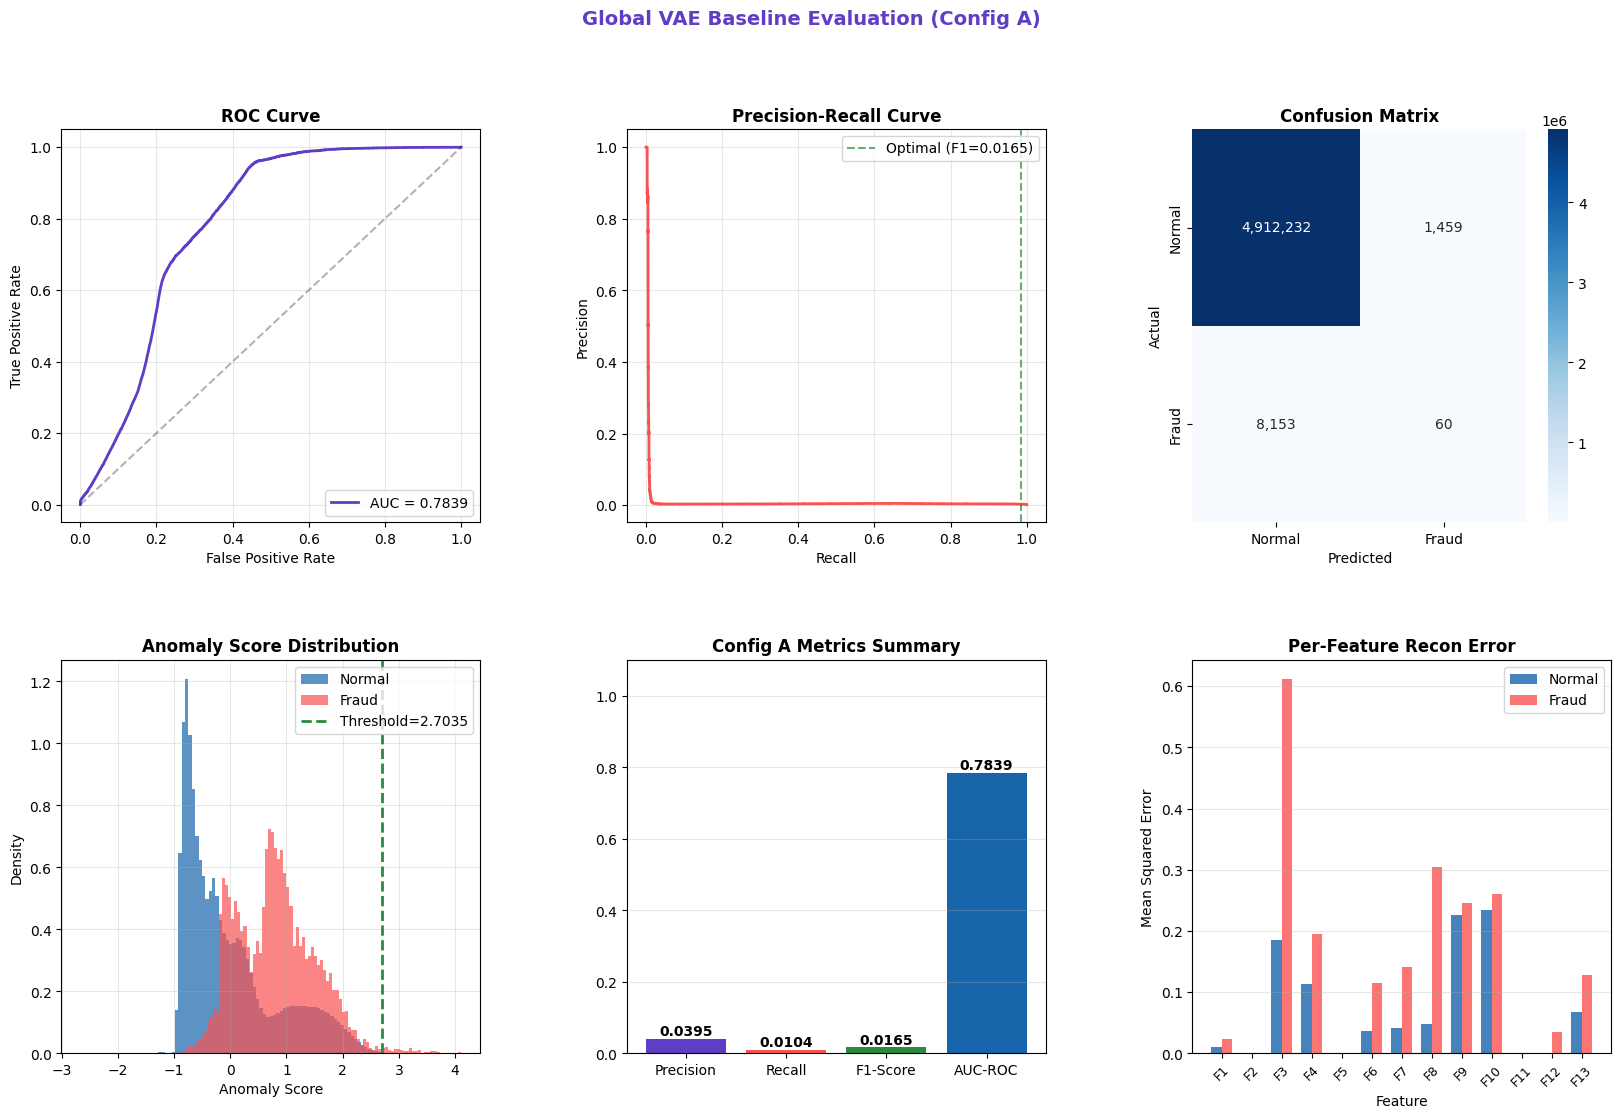

Saved: config_a_evaluation.png


In [10]:
# ============================================================
# CELL 10: Evaluation Visualizations
# ============================================================
print("=" * 60)
print("EVALUATION VISUALIZATIONS")
print("=" * 60)

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Global VAE Baseline Evaluation (Config A)',
             fontsize=14, fontweight='bold', color='#5f3dc4')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# 1. ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
fpr_curve, tpr_curve, _ = roc_curve(y_all, anomaly_scores)
ax1.plot(fpr_curve, tpr_curve, color='#5f3dc4', linewidth=2, label=f'AUC = {auc_roc:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.set_title('ROC Curve', fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# 2. Precision-Recall Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(recalls, precisions, color='#fa5252', linewidth=2)
ax2.axvline(x=recalls[optimal_idx], color='#2b8a3e', linestyle='--', alpha=0.7, label=f'Optimal (F1={f1:.4f})')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_all, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax3,
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
ax3.set_title('Confusion Matrix', fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# 4. Anomaly Score Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(anomaly_scores[y_all == 0], bins=100, alpha=0.7, color='#1864ab', label='Normal', density=True)
ax4.hist(anomaly_scores[y_all == 1], bins=100, alpha=0.7, color='#fa5252', label='Fraud', density=True)
ax4.axvline(x=optimal_threshold, color='#2b8a3e', linestyle='--', linewidth=2, label=f'Threshold={optimal_threshold:.4f}')
ax4.set_title('Anomaly Score Distribution', fontweight='bold')
ax4.set_xlabel('Anomaly Score')
ax4.set_ylabel('Density')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

# 5. Metrics Bar Chart
ax5 = fig.add_subplot(gs[1, 1])
metric_names = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metric_values = [precision, recall, f1, auc_roc]
colors = ['#5f3dc4', '#fa5252', '#2b8a3e', '#1864ab']
bars = ax5.bar(metric_names, metric_values, color=colors)
for bar, val in zip(bars, metric_values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_title('Config A Metrics Summary', fontweight='bold')
ax5.set_ylim(0, 1.1)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Per-feature Reconstruction Error (Fraud vs Normal)
ax6 = fig.add_subplot(gs[1, 2])
fraud_re_mean = recon_error_per_feature[y_all == 1].mean(axis=0)
normal_re_mean = recon_error_per_feature[y_all == 0].mean(axis=0)
x_pos = np.arange(len(feature_cols))
width = 0.35
ax6.bar(x_pos - width/2, normal_re_mean, width, label='Normal', color='#1864ab', alpha=0.8)
ax6.bar(x_pos + width/2, fraud_re_mean, width, label='Fraud', color='#fa5252', alpha=0.8)
ax6.set_title('Per-Feature Recon Error', fontweight='bold')
ax6.set_xlabel('Feature')
ax6.set_ylabel('Mean Squared Error')
ax6.set_xticks(x_pos)
ax6.set_xticklabels([f'F{i+1}' for i in range(len(feature_cols))], fontsize=9, rotation=45)
ax6.legend(loc='upper right')
ax6.grid(True, alpha=0.3, axis='y')

plt.savefig(f'{results_dir}/config_a_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: config_a_evaluation.png")


In [11]:
# ============================================================
# CELL 11: Save Model
# ============================================================
print("=" * 60)
print("SAVING MODEL")
print("=" * 60)

model_dir = f'{results_dir}/models'
os.makedirs(model_dir, exist_ok=True)

# Save encoder and decoder separately
vae.encoder.save(f'{model_dir}/global_vae_encoder.keras')
vae.decoder.save(f'{model_dir}/global_vae_decoder.keras')

# Save scaler
import pickle
with open(f'{model_dir}/global_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save threshold + score normalization stats (needed for inference reproducibility)
with open(f'{model_dir}/global_threshold.json', 'w') as f:
    json.dump({
        'threshold': float(optimal_threshold),
        'alpha': float(alpha),
        'recon_mean': float(recon_mean),
        'recon_std': float(recon_std),
        'kl_mean': float(kl_mean),
        'kl_std': float(kl_std),
    }, f)

print(f"  Encoder saved:  global_vae_encoder.keras")
print(f"  Decoder saved:  global_vae_decoder.keras")
print(f"  Scaler saved:   global_scaler.pkl")
print(f"  Threshold saved: global_threshold.json")


SAVING MODEL
  Encoder saved:  global_vae_encoder.keras
  Decoder saved:  global_vae_decoder.keras
  Scaler saved:   global_scaler.pkl
  Threshold saved: global_threshold.json


In [12]:
# ============================================================
# CELL 12: Verify Results Saved to Google Drive
# ============================================================
# All results are already saved permanently to Google Drive.
# No download needed - access them anytime from Drive.

import os
print("Results saved to Google Drive:")
for root, dirs, filenames in os.walk(results_dir):
    for filename in filenames:
        filepath = os.path.join(root, filename)
        size = os.path.getsize(filepath) / (1024)
        rel = os.path.relpath(filepath, results_dir)
        print(f"  {rel}  ({size:.0f} KB)")


Results saved to Google Drive:
  training_history.png  (105 KB)
  config_a_metrics.json  (0 KB)
  config_a_evaluation.png  (199 KB)
  models/global_vae_encoder.keras  (31 KB)
  models/global_vae_decoder.keras  (25 KB)
  models/global_scaler.pkl  (1 KB)
  models/global_threshold.json  (0 KB)


In [13]:
# ============================================================
# CELL 13: Final Summary
# ============================================================
print("\n" + "=" * 60)
print("GLOBAL VAE BASELINE (Config A) — COMPLETE!")
print("=" * 60)
print(f"""
Results:
  Precision:  {precision:.4f}
  Recall:     {recall:.4f}
  F1-Score:   {f1:.4f}
  AUC-ROC:    {auc_roc:.4f}
  FPR:        {fpr:.4f}
  Threshold:  {optimal_threshold:.4f}
  Train Time: {train_time:.1f}s

Files saved:
  config_a_evaluation.png     — 6-panel evaluation chart
  config_a_metrics.json       — All metrics in JSON
  training_history.png        — Loss curves
  models/                     — Saved encoder, decoder, scaler

Next notebook:
  Step 4: Train Stratified VAE Ensemble (Configs B, C, D)
  Step 5: Implement DSAA + Clustering
  Step 6: Run 7-way Ablation Study
""")


GLOBAL VAE BASELINE (Config A) — COMPLETE!

Results:
  Precision:  0.0395
  Recall:     0.0104
  F1-Score:   0.0165
  AUC-ROC:    0.7839
  FPR:        0.0004
  Threshold:  2.7035
  Train Time: 2978.3s

Files saved:
  config_a_evaluation.png     — 6-panel evaluation chart
  config_a_metrics.json       — All metrics in JSON
  training_history.png        — Loss curves
  models/                     — Saved encoder, decoder, scaler

Next notebook:
  Step 4: Train Stratified VAE Ensemble (Configs B, C, D)
  Step 5: Implement DSAA + Clustering
  Step 6: Run 7-way Ablation Study



In [14]:
# ============================================================
# CELL 14: Diagnostic Report (text-only — copy this to share)
# ============================================================
# Pulls together all the numbers we need to judge whether the
# baseline is healthy and whether CASH_OUT is fixed before moving
# on to the Stratified VAE.
# ============================================================
print("\n" + "=" * 70)
print("DIAGNOSTIC REPORT — CONFIG A (GLOBAL VAE BASELINE, 13 FEATURES)")
print("=" * 70)

# ---- Targets (from research plan) ----
TARGET_AUC      = 0.93
TARGET_F1       = 0.25
TARGET_CASHOUT_F1  = 0.20
TARGET_TRANSFER_F1 = 0.25
TARGET_PAYMENT_FPR = 0.05
TARGET_KL_STD      = 1.0   # below this = KL collapse

def status(actual, target, mode='ge'):
    if actual is None:
        return 'N/A'
    if mode == 'ge':
        return 'PASS' if actual >= target else 'FAIL'
    else:
        return 'PASS' if actual <= target else 'FAIL'

# ---- 1. Training health ----
print("\n[1] TRAINING HEALTH")
print(f"    Final epochs trained:      {len(history.history['total_loss'])}")
print(f"    Train time (seconds):      {train_time:.1f}")
print(f"    KL std on validation:      {kl_std:.4f}   (target > {TARGET_KL_STD}: {status(kl_std, TARGET_KL_STD)})")
print(f"    Recon mean on validation:  {recon_mean:.4f}")
if kl_std < TARGET_KL_STD:
    print("    ! KL COLLAPSE DETECTED — latent space not informative.")
    print("    ! Cause: free_bits too high or KL anneal too slow.")
else:
    print("    + KL is informative — latent space is being used.")

# ---- 2. Overall metrics vs targets ----
print("\n[2] OVERALL METRICS (test set)")
print(f"    Precision:   {precision:.4f}")
print(f"    Recall:      {recall:.4f}")
print(f"    F1-Score:    {f1:.4f}   (target >= {TARGET_F1}: {status(f1, TARGET_F1)})")
print(f"    AUC-ROC:     {auc_roc:.4f}   (target >= {TARGET_AUC}: {status(auc_roc, TARGET_AUC)})")
print(f"    FPR:         {fpr:.4f}")

# ---- 3. Per-type breakdown ----
print("\n[3] PER-TYPE BREAKDOWN")
for t in ['TRANSFER', 'CASH_OUT', 'PAYMENT']:
    m = per_type_metrics[t]
    if m['fraud_count'] > 0:
        target = TARGET_CASHOUT_F1 if t == 'CASH_OUT' else TARGET_TRANSFER_F1
        print(f"    {t:<10} F1={m['f1']:.4f}  AUC={m['auc']:.4f}  Recall={m['recall']:.4f}  "
              f"Detected={m['detected']}/{m['fraud_count']}  "
              f"(target F1 >= {target}: {status(m['f1'], target)})")
        print(f"               Recon mean = {m['recon_mean']:.4f}")
    else:
        print(f"    {t:<10} no fraud — {m['fp_count']:,} false positives  FPR={m['fpr']:.4f}  "
              f"(target FPR <= {TARGET_PAYMENT_FPR}: {status(m['fpr'], TARGET_PAYMENT_FPR, 'le')})")

# ---- 4. Problem detection ----
print("\n[4] PROBLEM DETECTION")
problems = []
if kl_std < TARGET_KL_STD:
    problems.append("KL_COLLAPSE: Latent space is not informative (kl_std too low).")
if auc_roc < TARGET_AUC:
    problems.append(f"LOW_AUC: AUC-ROC={auc_roc:.3f} below target {TARGET_AUC}.")
if f1 < TARGET_F1:
    problems.append(f"LOW_F1: Overall F1={f1:.3f} below target {TARGET_F1}.")
if per_type_metrics['CASH_OUT']['f1'] is not None and \
   per_type_metrics['CASH_OUT']['f1'] < TARGET_CASHOUT_F1:
    problems.append(f"CASHOUT_WEAK: CASH_OUT F1={per_type_metrics['CASH_OUT']['f1']:.3f} "
                    f"below target {TARGET_CASHOUT_F1} — main research problem still unresolved.")
if per_type_metrics['CASH_OUT']['recon_mean'] > 2.5 * per_type_metrics['TRANSFER']['recon_mean']:
    problems.append("CASHOUT_RECON_HIGH: CASH_OUT reconstruction error >2.5x TRANSFER — "
                    "single VAE struggles to learn both distributions.")
if per_type_metrics['PAYMENT']['fpr'] is not None and \
   per_type_metrics['PAYMENT']['fpr'] > TARGET_PAYMENT_FPR:
    problems.append(f"PAYMENT_FP: PAYMENT FPR={per_type_metrics['PAYMENT']['fpr']:.3f} "
                    f"above target {TARGET_PAYMENT_FPR}.")

if not problems:
    print("    No blocking problems detected. Baseline is healthy.")
else:
    for p in problems:
        print(f"    ! {p}")

# ---- 5. CASH_OUT focus ----
print("\n[5] CASH_OUT FOCUS (the core research problem)")
co = per_type_metrics['CASH_OUT']
if co['f1'] is not None:
    print(f"    Old (8 features):    F1=0.0370  Detected=152/4116")
    print(f"    New (13 features):   F1={co['f1']:.4f}  Detected={co['detected']}/{co['fraud_count']}")
    delta = co['f1'] - 0.0370
    if co['f1'] >= TARGET_CASHOUT_F1:
        verdict = "FIXED  — F9-F13 features have rescued CASH_OUT detection in the global VAE."
    elif co['f1'] >= 0.10:
        verdict = "IMPROVED — better than 8-feature baseline, but stratified VAE will lift it further."
    else:
        verdict = "STILL_WEAK — F9-F13 alone are not enough at the global level. " \
                  "Stratified VAE (Config D) is needed to overcome this."
    print(f"    Delta vs old:        {delta:+.4f}")
    print(f"    Verdict:             {verdict}")
    print()
    print("    Why CASH_OUT is hard at the global level:")
    print(f"      * recon_mean(CASH_OUT) = {co['recon_mean']:.4f}")
    print(f"      * recon_mean(TRANSFER) = {per_type_metrics['TRANSFER']['recon_mean']:.4f}")
    print("      * A single VAE averages both distributions; the stratified ensemble")
    print("        gives CASH_OUT its own VAE with 64-32-16 capacity (vs 32-16-8 here).")

# ---- 6. Recommendation ----
print("\n[6] RECOMMENDATION")
if not problems or (len(problems) == 1 and 'CASHOUT' in problems[0]):
    print("    -> Proceed to 04_Stratified_VAE.")
    print("       Expected improvement: Config D (Ensemble) F1 >= 0.35, "
          "CASH_OUT F1 >= 0.20.")
elif 'KL_COLLAPSE' in str(problems):
    print("    -> STOP. KL collapse must be fixed before continuing.")
    print("       Lower free_bits_lambda or reduce beta_anneal_epochs. Rerun this notebook.")
elif auc_roc < 0.85:
    print("    -> STOP. AUC-ROC too low — features or scaling are wrong.")
    print("       Re-check Feature Engineering and EDA outputs before continuing.")
else:
    print("    -> Proceed to 04_Stratified_VAE with caution.")
    print("       Stratification should compensate, but if Config D also fails the")
    print("       targets, revisit feature engineering (drop F11, drop F10 for CASH_OUT).")

print("\n" + "=" * 70)
print("END OF DIAGNOSTIC REPORT — copy text from [1] to [6] to share.")
print("=" * 70)


DIAGNOSTIC REPORT — CONFIG A (GLOBAL VAE BASELINE, 13 FEATURES)

[1] TRAINING HEALTH
    Final epochs trained:      50
    Train time (seconds):      2978.3
    KL std on validation:      0.0145   (target > 1.0: FAIL)
    Recon mean on validation:  0.9653
    ! KL COLLAPSE DETECTED — latent space not informative.
    ! Cause: free_bits too high or KL anneal too slow.

[2] OVERALL METRICS (test set)
    Precision:   0.0395
    Recall:      0.0104
    F1-Score:    0.0165   (target >= 0.25: FAIL)
    AUC-ROC:     0.7839   (target >= 0.93: FAIL)
    FPR:         0.0004

[3] PER-TYPE BREAKDOWN
    TRANSFER   F1=0.0345  AUC=0.9432  Recall=0.0176  Detected=72/4097  (target F1 >= 0.25: FAIL)
               Recon mean = 0.6950
    CASH_OUT   F1=0.0010  AUC=0.9369  Recall=0.0005  Detected=2/4116  (target F1 >= 0.2: FAIL)
               Recon mean = 0.7353
    PAYMENT    no fraud — 1,985 false positives  FPR=0.0009  (target FPR <= 0.05: PASS)

[4] PROBLEM DETECTION
    ! KL_COLLAPSE: Latent spac